In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn import metrics
import os
import fiona

In [2]:
fire_data = gpd.read_file("../total_fire.geojson")
ain_data = gpd.read_file("../datasets_par_departement/departement-01-ain-original.geojson")
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
yvelines_data = gpd.read_file("../datasets_par_departement/departement-78-yvelines-original.geojson")

In [3]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

In [4]:
fire_data = calculer_duree(fire_data, 'date_debut', 'date_fin')
ain_data = calculer_duree(ain_data, 'date_debut', 'date_fin')
doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
yvelines_data = calculer_duree(yvelines_data, 'date_debut', 'date_fin')
yvelines_data['weekday'] = yvelines_data['date'].dt.weekday

In [5]:
fire_data.head()

,hex_id,raison_sortie,date_debut,date_fin,label,year,date,departement,geometry,duree
0,871f91c4dffffff,NATURELS,2018-01-05 17:41:19,2018-01-05 18:45:21,1.0,2018.0,2018-01-05,departement-01-ain,"POLYGON ((5.39217 46.12447, 5.39416 46.11236, ...",0 days 01:04:02
1,871f91c6effffff,NATURELS,2018-01-06 17:56:49,2018-01-06 19:37:07,1.0,2018.0,2018-01-06,departement-01-ain,"POLYGON ((5.32470 46.15261, 5.32670 46.14050, ...",0 days 01:40:18
2,871f910d6ffffff,NATURELS,2018-01-12 08:43:15,2018-01-12 09:36:25,1.0,2018.0,2018-01-12,departement-01-ain,"POLYGON ((5.68525 45.86548, 5.68720 45.85332, ...",0 days 00:53:10
3,871f91c9bffffff,NATURELS,2018-01-15 17:55:58,2018-01-15 18:59:14,1.0,2018.0,2018-01-15,departement-01-ain,"POLYGON ((5.04235 45.87305, 5.04438 45.86093, ...",0 days 01:03:16
4,871f910e3ffffff,NATURELS,2018-01-19 22:57:16,2018-01-20 00:21:51,1.0,2018.0,2018-01-19,departement-01-ain,"POLYGON ((5.76585 45.95039, 5.76778 45.93823, ...",0 days 01:24:35


In [6]:
fire_data['centroid'] = fire_data.geometry.centroid
fire_data['centroid_lon'] = fire_data['centroid'].x
fire_data['centroid_lat'] = fire_data['centroid'].y

doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y

ain_data['centroid'] = ain_data.geometry.centroid
ain_data['centroid_lon'] = ain_data['centroid'].x
ain_data['centroid_lat'] = ain_data['centroid'].y

yvelines_data['centroid'] = yvelines_data.geometry.centroid
yvelines_data['centroid_lon'] = yvelines_data['centroid'].x
yvelines_data['centroid_lat'] = yvelines_data['centroid'].y

<ipython-input-6-d093f4043644>:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  fire_data['centroid'] = fire_data.geometry.centroid
<ipython-input-6-d093f4043644>:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  doubs_data['centroid'] = doubs_data.geometry.centroid
<ipython-input-6-d093f4043644>:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ain_data['centroid'] = ain_data.geometry.centroid
<ipython-input-6-d093f4043644>:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a

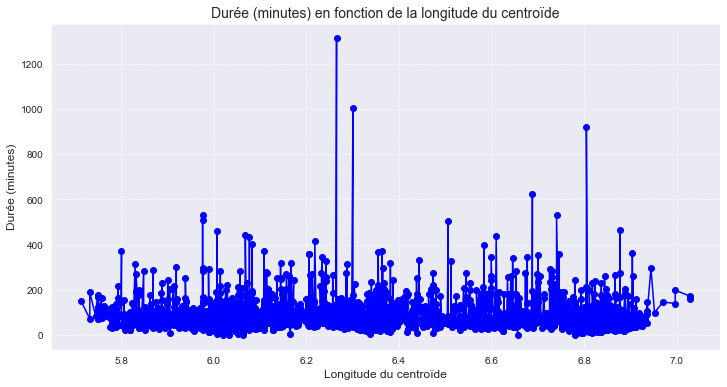

In [7]:
if 'centroid_lon' in doubs_data.columns and 'duree_minutes' in doubs_data.columns:
    sorted_data = doubs_data.sort_values(by='centroid_lon')
    
    plt.figure(figsize=(12, 6))
    plt.plot(sorted_data['centroid_lon'], sorted_data['duree_minutes'], marker='o', linestyle='-', color='blue')
    
    plt.title('Durée (minutes) en fonction de la longitude du centroïde', fontsize=14)
    plt.xlabel('Longitude du centroïde', fontsize=12)
    plt.ylabel('Durée (minutes)', fontsize=12)
    
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.show()
else:
    print("Les colonnes 'centroid_lon' ou 'duree_minutes' sont manquantes dans le GeoDataFrame.")

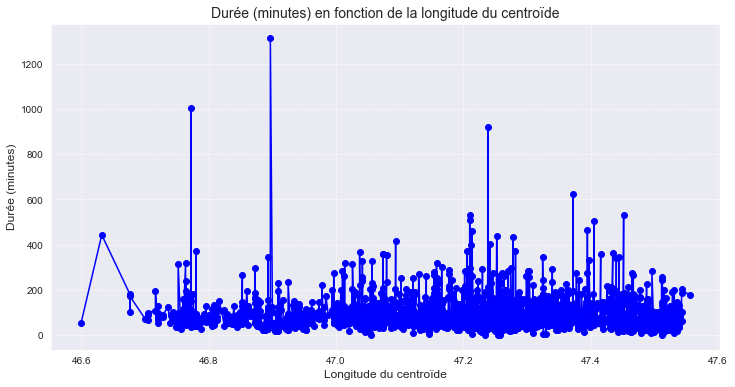

In [8]:
if 'centroid_lat' in doubs_data.columns and 'duree_minutes' in doubs_data.columns:
    sorted_data = doubs_data.sort_values(by='centroid_lat')
    
    plt.figure(figsize=(12, 6))
    plt.plot(sorted_data['centroid_lat'], sorted_data['duree_minutes'], marker='o', linestyle='-', color='blue')
    
    plt.title('Durée (minutes) en fonction de la longitude du centroïde', fontsize=14)
    plt.xlabel('Longitude du centroïde', fontsize=12)
    plt.ylabel('Durée (minutes)', fontsize=12)
    
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.show()
else:
    print("Les colonnes 'centroid_lat' ou 'duree_minutes' sont manquantes dans le GeoDataFrame.")

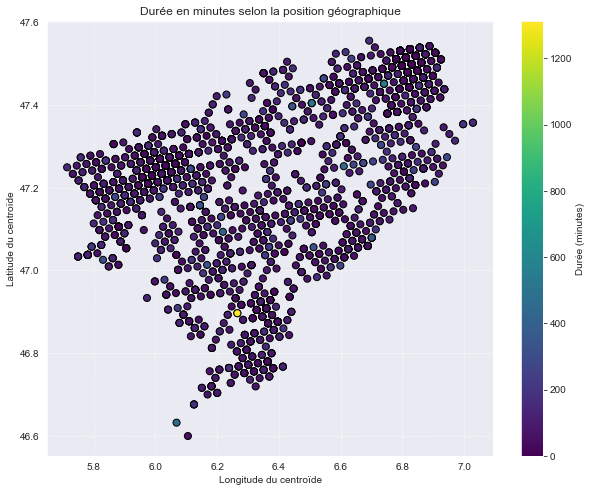

In [9]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(doubs_data['centroid_lon'], doubs_data['centroid_lat'], 
                       c=doubs_data['duree_minutes'], cmap='viridis', s=50, edgecolor='k')
plt.colorbar(scatter, label='Durée (minutes)')
plt.title('Durée en minutes selon la position géographique')
plt.xlabel('Longitude du centroïde')
plt.ylabel('Latitude du centroïde')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

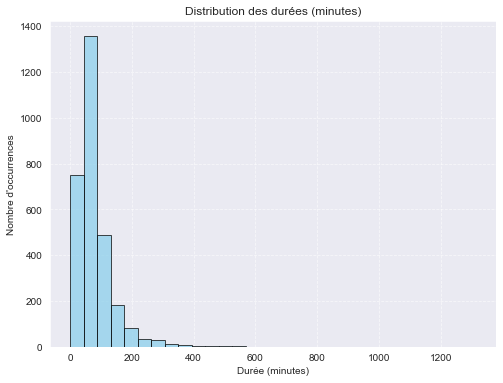

In [10]:
plt.figure(figsize=(8, 6))
plt.hist(doubs_data['duree_minutes'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution des durées (minutes)')
plt.xlabel('Durée (minutes)')
plt.ylabel('Nombre d\'occurrences')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

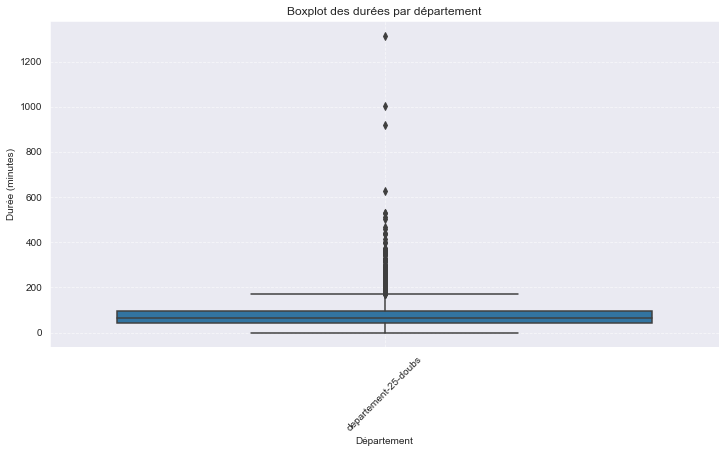

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='departement', y='duree_minutes', data=doubs_data)
plt.title('Boxplot des durées par département')
plt.xlabel('Département')
plt.ylabel('Durée (minutes)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

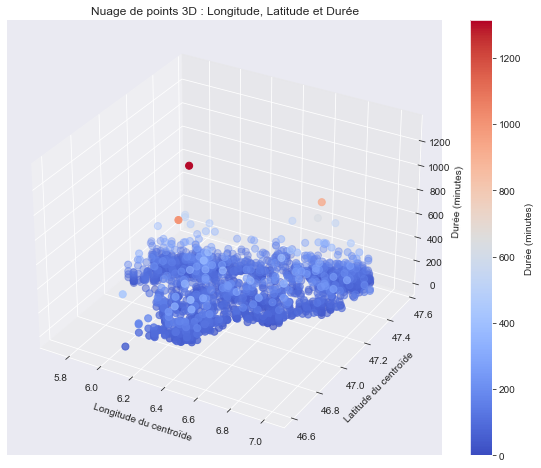

In [12]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(doubs_data['centroid_lon'], doubs_data['centroid_lat'], doubs_data['duree_minutes'], 
                     c=doubs_data['duree_minutes'], cmap='coolwarm', s=50)
ax.set_title('Nuage de points 3D : Longitude, Latitude et Durée')
ax.set_xlabel('Longitude du centroïde')
ax.set_ylabel('Latitude du centroïde')
ax.set_zlabel('Durée (minutes)')
fig.colorbar(scatter, label='Durée (minutes)')
plt.show()

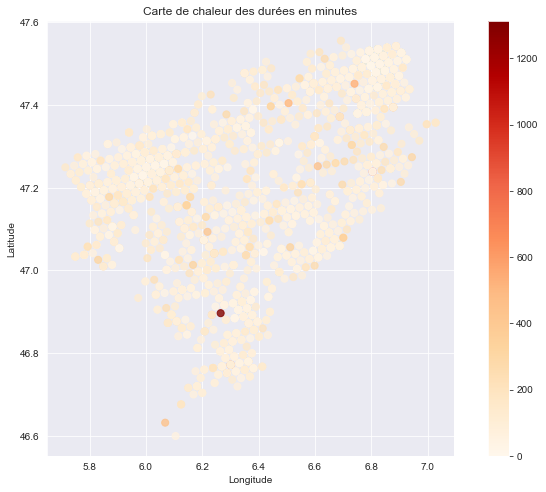

In [13]:
gdf = gpd.GeoDataFrame(doubs_data, geometry=gpd.points_from_xy(doubs_data['centroid_lon'], doubs_data['centroid_lat']))

gdf.plot(column='duree_minutes', cmap='OrRd', legend=True, figsize=(12, 8), markersize=50, alpha=0.8)
plt.title('Carte de chaleur des durées en minutes')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

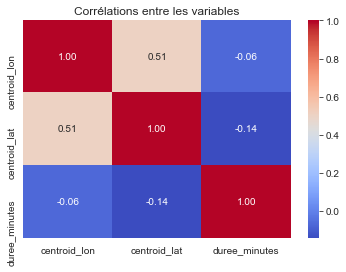

In [14]:
correlation_matrix = doubs_data[['centroid_lon', 'centroid_lat', 'duree_minutes']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Corrélations entre les variables')
plt.show()

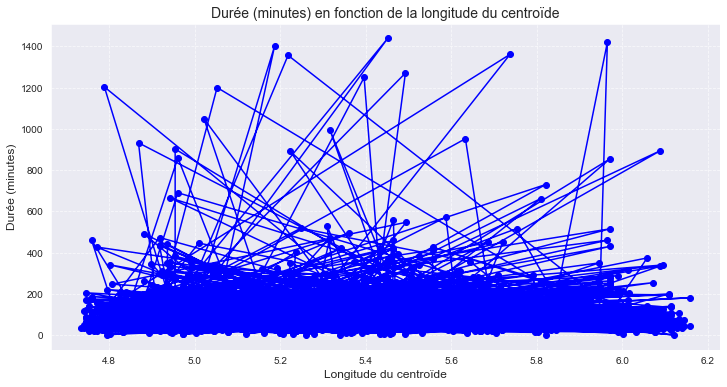

In [15]:
if 'centroid_lon' in ain_data.columns and 'duree_minutes' in ain_data.columns:
    sorted_data = ain_data.sort_values(by='centroid_lon')
    
    plt.figure(figsize=(12, 6))
    plt.plot(ain_data['centroid_lon'], ain_data['duree_minutes'], marker='o', linestyle='-', color='blue')
    
    plt.title('Durée (minutes) en fonction de la longitude du centroïde', fontsize=14)
    plt.xlabel('Longitude du centroïde', fontsize=12)
    plt.ylabel('Durée (minutes)', fontsize=12)
    
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.show()
else:
    print("Les colonnes 'centroid_lon' ou 'duree_minutes' sont manquantes dans le GeoDataFrame.")

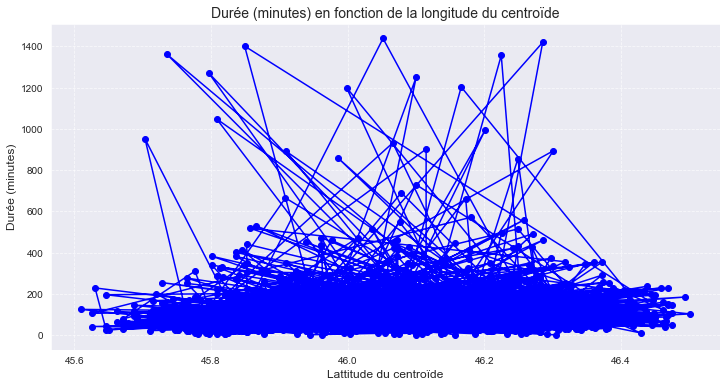

In [16]:
if 'centroid_lat' in ain_data.columns and 'duree_minutes' in ain_data.columns:
    sorted_data = ain_data.sort_values(by='centroid_lat')
    
    plt.figure(figsize=(12, 6))
    plt.plot(ain_data['centroid_lat'], ain_data['duree_minutes'], marker='o', linestyle='-', color='blue')
    
    plt.title('Durée (minutes) en fonction de la longitude du centroïde', fontsize=14)
    plt.xlabel('Lattitude du centroïde', fontsize=12)
    plt.ylabel('Durée (minutes)', fontsize=12)
    
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.show()
else:
    print("Les colonnes 'centroid_lat' ou 'duree_minutes' sont manquantes dans le GeoDataFrame.")

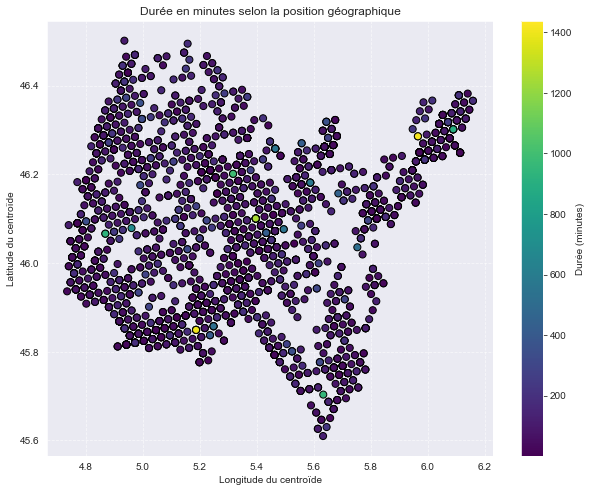

In [17]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(ain_data['centroid_lon'], ain_data['centroid_lat'], 
                       c=ain_data['duree_minutes'], cmap='viridis', s=50, edgecolor='k')
plt.colorbar(scatter, label='Durée (minutes)')
plt.title('Durée en minutes selon la position géographique')
plt.xlabel('Longitude du centroïde')
plt.ylabel('Latitude du centroïde')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

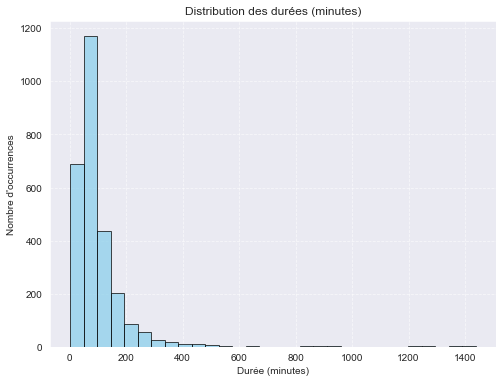

In [18]:
plt.figure(figsize=(8, 6))
plt.hist(ain_data['duree_minutes'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution des durées (minutes)')
plt.xlabel('Durée (minutes)')
plt.ylabel('Nombre d\'occurrences')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

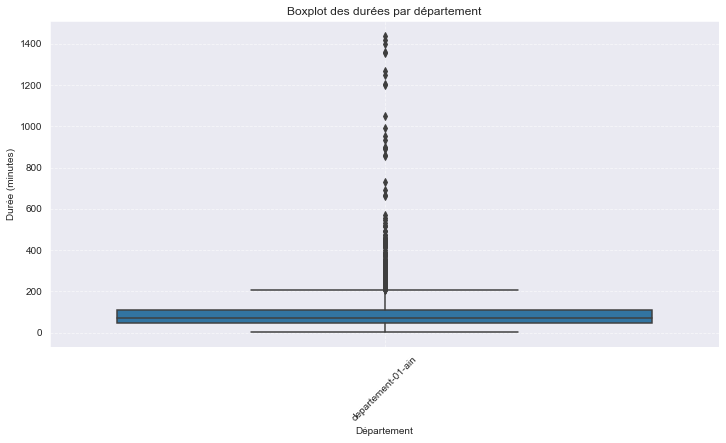

In [19]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='departement', y='duree_minutes', data=ain_data)
plt.title('Boxplot des durées par département')
plt.xlabel('Département')
plt.ylabel('Durée (minutes)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

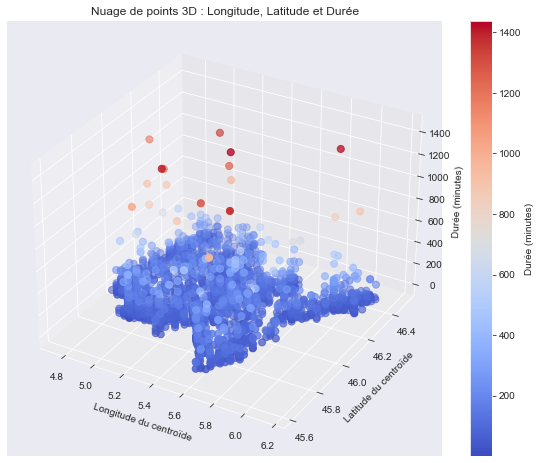

In [20]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(ain_data['centroid_lon'], ain_data['centroid_lat'], ain_data['duree_minutes'], 
                     c=ain_data['duree_minutes'], cmap='coolwarm', s=50)
ax.set_title('Nuage de points 3D : Longitude, Latitude et Durée')
ax.set_xlabel('Longitude du centroïde')
ax.set_ylabel('Latitude du centroïde')
ax.set_zlabel('Durée (minutes)')
fig.colorbar(scatter, label='Durée (minutes)')
plt.show()

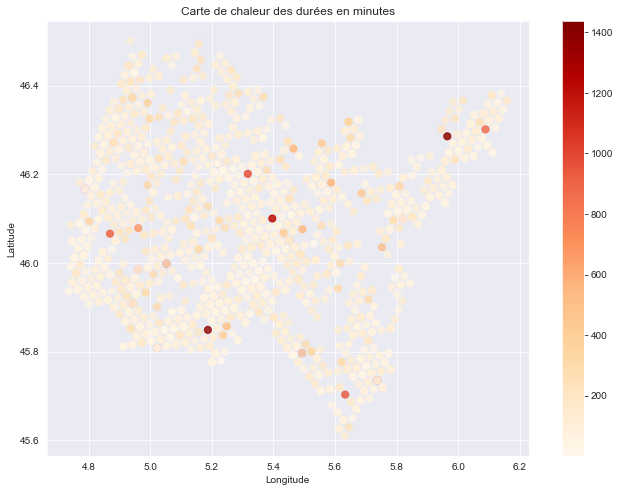

In [21]:
gdf = gpd.GeoDataFrame(ain_data, geometry=gpd.points_from_xy(ain_data['centroid_lon'], ain_data['centroid_lat']))

gdf.plot(column='duree_minutes', cmap='OrRd', legend=True, figsize=(12, 8), markersize=50, alpha=0.8)
plt.title('Carte de chaleur des durées en minutes')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

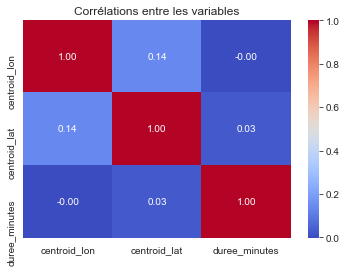

In [22]:
correlation_matrix = ain_data[['centroid_lon', 'centroid_lat', 'duree_minutes']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Corrélations entre les variables')
plt.show()

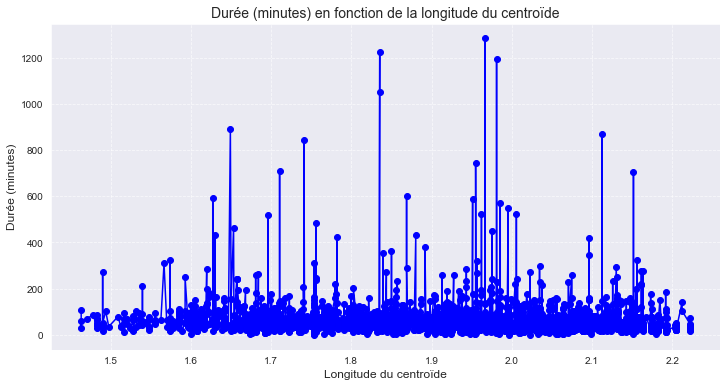

In [23]:
if 'centroid_lon' in yvelines_data.columns and 'duree_minutes' in yvelines_data.columns:
    sorted_data = yvelines_data.sort_values(by='centroid_lon')
    
    plt.figure(figsize=(12, 6))
    plt.plot(sorted_data['centroid_lon'], sorted_data['duree_minutes'], marker='o', linestyle='-', color='blue')
    
    plt.title('Durée (minutes) en fonction de la longitude du centroïde', fontsize=14)
    plt.xlabel('Longitude du centroïde', fontsize=12)
    plt.ylabel('Durée (minutes)', fontsize=12)
    
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.show()
else:
    print("Les colonnes 'centroid_lon' ou 'duree_minutes' sont manquantes dans le GeoDataFrame.")


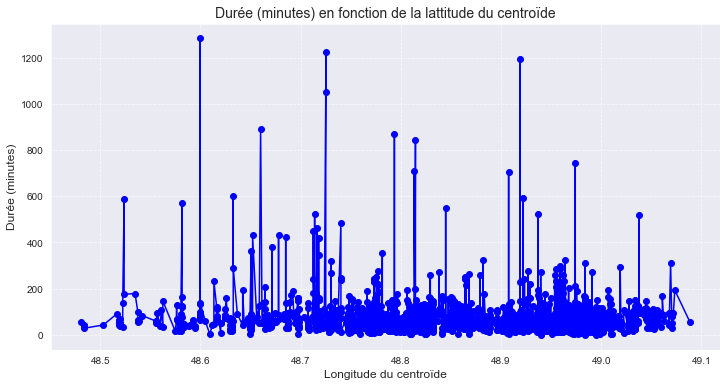

In [24]:
if 'centroid_lat' in yvelines_data.columns and 'duree_minutes' in yvelines_data.columns:
    sorted_data = yvelines_data.sort_values(by='centroid_lat')
    
    plt.figure(figsize=(12, 6))
    plt.plot(sorted_data['centroid_lat'], sorted_data['duree_minutes'], marker='o', linestyle='-', color='blue')
    
    plt.title('Durée (minutes) en fonction de la lattitude du centroïde', fontsize=14)
    plt.xlabel('Longitude du centroïde', fontsize=12)
    plt.ylabel('Durée (minutes)', fontsize=12)
    
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.show()
else:
    print("Les colonnes 'centroid_lat' ou 'duree_minutes' sont manquantes dans le GeoDataFrame.")


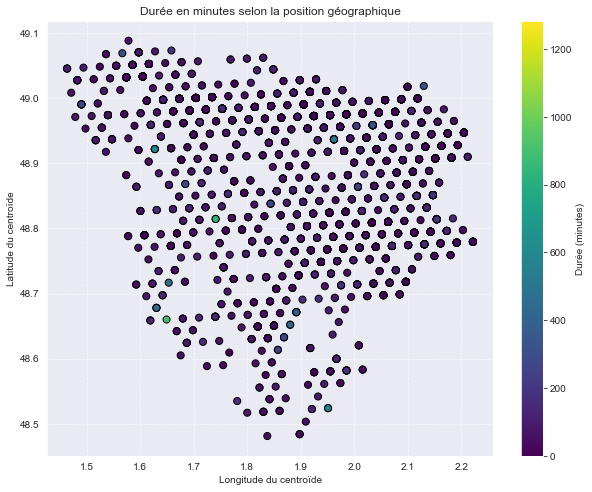

In [25]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(yvelines_data['centroid_lon'], yvelines_data['centroid_lat'], 
                       c=yvelines_data['duree_minutes'], cmap='viridis', s=50, edgecolor='k')
plt.colorbar(scatter, label='Durée (minutes)')
plt.title('Durée en minutes selon la position géographique')
plt.xlabel('Longitude du centroïde')
plt.ylabel('Latitude du centroïde')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

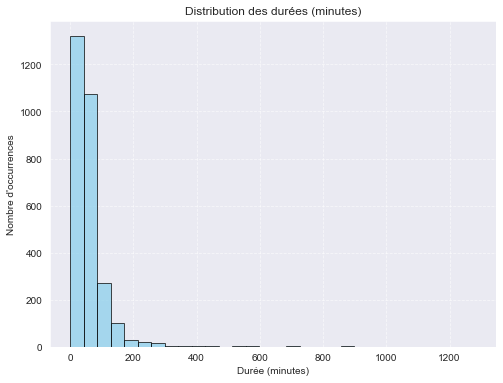

In [26]:
plt.figure(figsize=(8, 6))
plt.hist(yvelines_data['duree_minutes'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution des durées (minutes)')
plt.xlabel('Durée (minutes)')
plt.ylabel('Nombre d\'occurrences')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

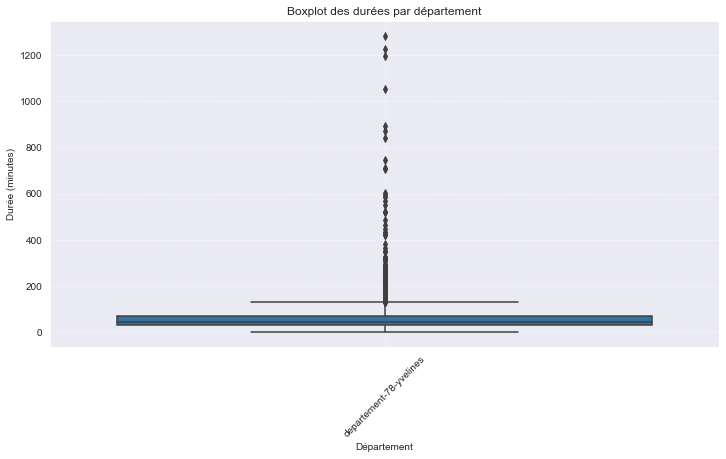

In [27]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='departement', y='duree_minutes', data=yvelines_data)
plt.title('Boxplot des durées par département')
plt.xlabel('Département')
plt.ylabel('Durée (minutes)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

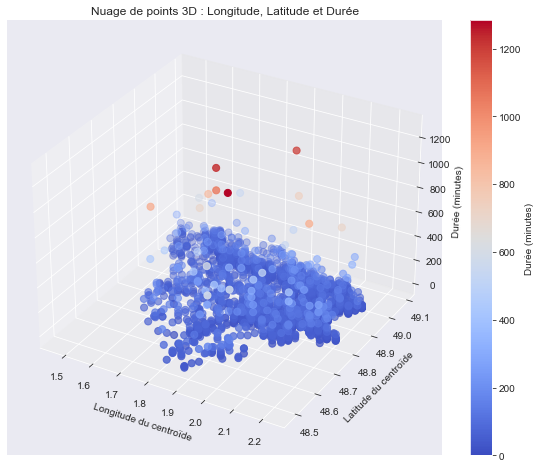

In [28]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(yvelines_data['centroid_lon'], yvelines_data['centroid_lat'], yvelines_data['duree_minutes'], 
                     c=yvelines_data['duree_minutes'], cmap='coolwarm', s=50)
ax.set_title('Nuage de points 3D : Longitude, Latitude et Durée')
ax.set_xlabel('Longitude du centroïde')
ax.set_ylabel('Latitude du centroïde')
ax.set_zlabel('Durée (minutes)')
fig.colorbar(scatter, label='Durée (minutes)')
plt.show()

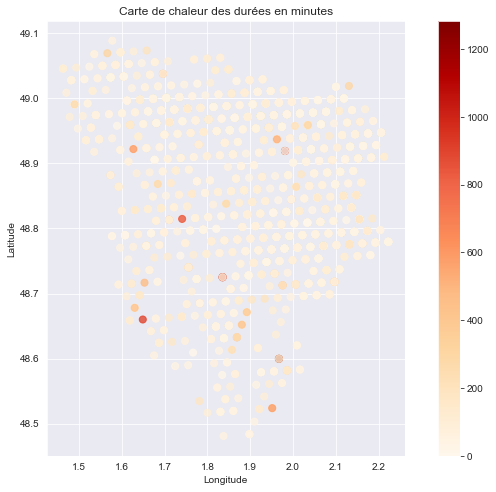

In [29]:
gdf = gpd.GeoDataFrame(yvelines_data, geometry=gpd.points_from_xy(yvelines_data['centroid_lon'], yvelines_data['centroid_lat']))

gdf.plot(column='duree_minutes', cmap='OrRd', legend=True, figsize=(12, 8), markersize=50, alpha=0.8)
plt.title('Carte de chaleur des durées en minutes')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [30]:
correlation_matrix = yvelines_data[['centroid_lon', 'centroid_lat', 'duree_minutes', 'month', 'weekday']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Corrélations entre les variables')
plt.show()

KeyError: "['month'] not in index"

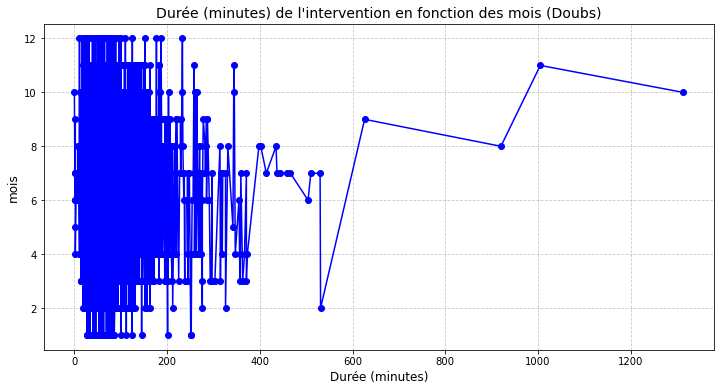

In [37]:
if 'month' in doubs_data.columns and 'duree_minutes' in doubs_data.columns:
    sorted_data = doubs_data.sort_values(by='duree_minutes')
    
    plt.figure(figsize=(12, 6))
    plt.plot(sorted_data['duree_minutes'], sorted_data['month'], marker='o', linestyle='-', color='blue')
    
    plt.title('Durée (minutes) de l\'intervention en fonction des mois (Doubs)', fontsize=14)
    plt.xlabel('Durée (minutes)', fontsize=12)
    plt.ylabel('mois', fontsize=12)
    
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.show()
else:
    print("Les colonnes 'month' ou 'duree_minutes' sont manquantes dans le GeoDataFrame.")